# Análise do Titanic — SQL (SQLite) + Estatística em Python puro

**Objetivo:** explorar o dataset do Titanic usando **SQL** (SQLite) para consultar/agrupar os dados e **estatística descritiva implementada em Python puro** — média, mediana, moda, variância e desvio-padrão calculados na mão, sem usar `pandas.mean()` e afins.

> **Regra de ouro deste projeto:** o pandas serve só para **carregar e organizar** os dados (e depois **validar** os cálculos). As 5 métricas são implementadas manualmente, para entender como cada uma funciona por dentro.

## Seção 1 — Setup, carga dos dados e exploração inicial

Nesta seção vamos:
1. Importar as bibliotecas.
2. Ler o `titanic.csv` com pandas.
3. Criar um banco SQLite e carregar os dados nele (com `connection` e `cursor` explícitos).
4. Fazer uma exploração inicial via SQL.

### Conceitos rápidos
- **Por que SQLite e não só pandas?** O foco é treinar SQL num banco de verdade. SQLite é um banco completo dentro de **um único arquivo** `.db`, sem servidor para instalar.
- **O módulo `sqlite3` já vem com Python** (biblioteca padrão) — não precisa instalar nada.
- **`connection` x `cursor`:** a *connection* é o vínculo com o arquivo do banco e controla as transações (`commit`). O *cursor* é quem executa o SQL e percorre o resultado (`fetchone`/`fetchall`).

### 1.1 — Importar bibliotecas

- `pandas`: apenas para **ler e organizar** o CSV (NÃO para calcular as métricas).
- `sqlite3`: driver do banco SQLite (biblioteca padrão, já vem embutido).
- `os`: montar caminhos de arquivo de forma portável.

In [52]:
import pandas as pd
import sqlite3
import os

print("pandas:", pd.__version__)
print("motor SQLite:", sqlite3.sqlite_version)

pandas: 2.3.3
motor SQLite: 3.50.4


### 1.2 — Ler o `titanic.csv`

O notebook roda dentro da pasta `notebooks/`, então o CSV está em `../data/titanic.csv`.

O `pd.read_csv` já entende vírgulas dentro de aspas (importante no campo `Name`) e infere os tipos das colunas. Onde o valor está vazio, o pandas coloca **`NaN`** ("não é um número") — vamos tratar isso na hora de gravar no banco.

In [53]:
CSV_PATH = os.path.join("..", "data", "titanic.csv")

df = pd.read_csv(CSV_PATH)

print("Dimensões (linhas, colunas):", df.shape)
print("Colunas:", list(df.columns))

# Espiar as primeiras linhas (df.head() renderiza uma tabela)
df.head()

Dimensões (linhas, colunas): (891, 12)
Colunas: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 1.3 — Criar o banco SQLite e carregar os dados

Aqui aparecem a `connection` e o `cursor` na prática:
1. `sqlite3.connect(...)` cria/abre o arquivo `../data/titanic.db` e devolve a **connection**.
2. `con.cursor()` cria o **cursor**, que executa os comandos.
3. `DROP TABLE IF EXISTS` + `CREATE TABLE`: definimos a tabela `passengers` com os tipos certos (`INTEGER`, `REAL`, `TEXT`). O `DROP` deixa a célula **reexecutável** sem erro de "tabela já existe".
4. `cur.executemany(...)` insere todas as linhas de uma vez com **parâmetros `?`** (forma segura: evita SQL injection e cuida do escape).
5. `con.commit()` **confirma a transação** — sem isso, nada é gravado de fato no arquivo.

**Detalhe importante (NaN → NULL):** o `sqlite3` só aceita `int`, `float`, `str`, `bytes` e `None` nativos do Python. O pandas entrega `NaN` para vazios e números como tipos do numpy. Por isso as funções `para_inteiro`/`para_decimal`/`para_texto` convertem cada valor para o tipo nativo e transformam `NaN` em `None` (que vira `NULL` no SQL).

> Repare na divisão de papéis: o **cursor** executa o SQL; a **connection** confirma (`commit`).

In [54]:
DB_PATH = os.path.join("..", "data", "titanic.db")

# Conversores: tipo nativo do Python; NaN/None viram None (NULL no SQL)
def para_inteiro(valor):
    """Converte para int nativo; vazio (NaN/None) vira None (NULL)."""
    return None if pd.isna(valor) else int(valor)

def para_decimal(valor):
    """Converte para float nativo; vazio (NaN/None) vira None (NULL)."""
    return None if pd.isna(valor) else float(valor)

def para_texto(valor):
    """Converte para str; vazio (NaN/None) vira None (NULL)."""
    return None if pd.isna(valor) else str(valor)

# Montar a lista de registros já com os tipos tratados
registros = [
    (
        para_inteiro(linha.PassengerId), para_inteiro(linha.Survived), para_inteiro(linha.Pclass),
        para_texto(linha.Name), para_texto(linha.Sex), para_decimal(linha.Age),
        para_inteiro(linha.SibSp), para_inteiro(linha.Parch), para_texto(linha.Ticket),
        para_decimal(linha.Fare), para_texto(linha.Cabin), para_texto(linha.Embarked),
    )
    for linha in df.itertuples(index=False)
]

# 1) Conexao com o arquivo do banco
con = sqlite3.connect(DB_PATH)
# 2) Cursor para executar comandos
cur = con.cursor()

# 3) (Re)criar a tabela com os tipos corretos
cur.execute("DROP TABLE IF EXISTS passengers")
cur.execute("""
    CREATE TABLE passengers (
        PassengerId INTEGER PRIMARY KEY,
        Survived    INTEGER,
        Pclass      INTEGER,
        Name        TEXT,
        Sex         TEXT,
        Age         REAL,
        SibSp       INTEGER,
        Parch       INTEGER,
        Ticket      TEXT,
        Fare        REAL,
        Cabin       TEXT,
        Embarked    TEXT
    )
""")

# 4) Inserir todos os registros de uma vez
cur.executemany(
    "INSERT INTO passengers VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)",
    registros,
)

# 5) Confirmar a transacao (sem isso, nada e gravado no arquivo)
con.commit()

print(f"Banco criado em: {DB_PATH}")
print(f"Registros inseridos: {len(registros)}")

Banco criado em: ..\data\titanic.db
Registros inseridos: 891


### 1.4 — Exploração inicial (via SQL)

Agora usamos o cursor para fazer as primeiras perguntas ao banco:
- **Esquema** da tabela (`PRAGMA table_info`).
- **Total de linhas**.
- **Amostra** das 5 primeiras linhas.
- **Valores faltando** (`NULL`) nas colunas críticas.
- **Distribuição** das variáveis categóricas.

Tudo isso é SQL — ainda **sem calcular estatísticas**; isso virá nas próximas seções, em Python puro.

In [55]:
print("=== Esquema da tabela 'passengers' ===")
for info_coluna in cur.execute("PRAGMA table_info(passengers)").fetchall():
    # info_coluna = (id, nome, tipo, notnull, default, pk)
    print(f"  {info_coluna[1]:<12} {info_coluna[2]}")

total = cur.execute("SELECT COUNT(*) FROM passengers").fetchone()[0]
print(f"\nTotal de passageiros: {total}")

=== Esquema da tabela 'passengers' ===
  PassengerId  INTEGER
  Survived     INTEGER
  Pclass       INTEGER
  Name         TEXT
  Sex          TEXT
  Age          REAL
  SibSp        INTEGER
  Parch        INTEGER
  Ticket       TEXT
  Fare         REAL
  Cabin        TEXT
  Embarked     TEXT

Total de passageiros: 891


In [56]:
print("=== Amostra (5 primeiras linhas) ===")
for linha in cur.execute("SELECT PassengerId, Survived, Pclass, Name, Sex, Age, Fare FROM passengers LIMIT 5"):
    print(linha)

=== Amostra (5 primeiras linhas) ===
(1, 0, 3, 'Braund, Mr. Owen Harris', 'male', 22.0, 7.25)
(2, 1, 1, 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'female', 38.0, 71.2833)
(3, 1, 3, 'Heikkinen, Miss. Laina', 'female', 26.0, 7.925)
(4, 1, 1, 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'female', 35.0, 53.1)
(5, 0, 3, 'Allen, Mr. William Henry', 'male', 35.0, 8.05)


In [57]:
print("=== Valores faltando (NULL) ===")
for coluna in ["Age", "Cabin", "Embarked", "Fare"]:
    faltando = cur.execute(f"SELECT COUNT(*) FROM passengers WHERE {coluna} IS NULL").fetchone()[0]
    print(f"  {coluna:<10}: {faltando} faltando ({faltando/total:.1%})")

=== Valores faltando (NULL) ===
  Age       : 177 faltando (19.9%)
  Cabin     : 687 faltando (77.1%)
  Embarked  : 2 faltando (0.2%)
  Fare      : 0 faltando (0.0%)


In [58]:
print("=== Distribuicoes (categoricas) ===")

print("\nSurvived (0 = morreu, 1 = sobreviveu):")
for valor, quantidade in cur.execute("SELECT Survived, COUNT(*) FROM passengers GROUP BY Survived"):
    print(f"  {valor}: {quantidade}")

print("\nPclass (classe do bilhete):")
for valor, quantidade in cur.execute("SELECT Pclass, COUNT(*) FROM passengers GROUP BY Pclass ORDER BY Pclass"):
    print(f"  {valor}: {quantidade}")

print("\nSex:")
for valor, quantidade in cur.execute("SELECT Sex, COUNT(*) FROM passengers GROUP BY Sex"):
    print(f"  {valor}: {quantidade}")

print("\nEmbarked (porto de embarque):")
for valor, quantidade in cur.execute("SELECT Embarked, COUNT(*) FROM passengers GROUP BY Embarked"):
    print(f"  {valor}: {quantidade}")

=== Distribuicoes (categoricas) ===

Survived (0 = morreu, 1 = sobreviveu):
  0: 549
  1: 342

Pclass (classe do bilhete):
  1: 216
  2: 184
  3: 491

Sex:
  female: 314
  male: 577

Embarked (porto de embarque):
  None: 2
  C: 168
  Q: 77
  S: 644


### Interpretação inicial

- **891 passageiros** no dataset. Dos quais **549 morreram (0)** e **342 sobreviveram (1)** — já dá pra sentir que a maioria não sobreviveu.
- **3ª classe domina** (491 pessoas), contra 216 na 1ª e 184 na 2ª — um navio socialmente desigual.
- **Mais homens (577) do que mulheres (314)**.
- **Dados faltando:** `Age` falta em ~20% (177) e `Cabin` em ~77% (687) — isso vai exigir cuidado nas análises de idade. `Embarked` só falta em 2 registros.

> **Fim da Seção 1.** A `connection` (`con`) e o `cursor` (`cur`) ficam abertos de propósito para reutilizarmos nas próximas seções (fecharemos com `con.close()` no fim do notebook).

## Seção 2 — Análises com SQL (8+ queries)

A partir daqui, cada query é uma subseção. Em cada uma: explico **o que ela responde**, mostro a **query formatada**, comento as **cláusulas** e **interpreto** o resultado.

> Para **exibir** o resultado como tabela uso `pd.read_sql_query(sql, con)`. Quem faz o trabalho é o **SQL rodando no SQLite** — o pandas aqui só busca e organiza a saída (uso permitido pelo CLAUDE.md).

### Query 1 — Taxa de sobrevivência geral

**Pergunta:** de todos os passageiros, qual a porcentagem que sobreviveu?

A coluna `Survived` vale `0` (morreu) ou `1` (sobreviveu). Por isso, **somar** a coluna (`SUM`) já dá o número de sobreviventes, e dividir pelo **total** (`COUNT`) dá a proporção.

**Cláusulas:**
- `COUNT(*)` — conta todas as linhas (total de passageiros).
- `SUM(Survived)` — soma os `1`s, ou seja, o número de sobreviventes.
- `100.0 * ... / ...` — o `100.0` (com casa decimal) força a **divisão decimal**; sem isso o SQLite faria divisão **inteira** e o resultado viria `0`.
- `ROUND(..., 2)` — arredonda para 2 casas decimais.
- `AS ...` — dá um **apelido** legível para cada coluna do resultado.

In [59]:
consulta_1 = """
SELECT
    COUNT(*)                                   AS total_passageiros,
    SUM(Survived)                              AS total_sobreviventes,
    ROUND(100.0 * SUM(Survived) / COUNT(*), 2) AS taxa_sobrevivencia_pct
FROM passengers
"""

pd.read_sql_query(consulta_1, con)

,total_passageiros,total_sobreviventes,taxa_sobrevivencia_pct
0,891,342,38.38


**Interpretação:** dos **891 passageiros**, apenas **342 sobreviveram** — taxa de **38,38%**. Ou seja, **quase 2 em cada 3 pessoas morreram**.

Esse valor é a nossa **linha de base**. Nas próximas queries vamos quebrar por **classe** e **sexo** para descobrir *quem* tinha chance acima ou abaixo desses 38%.

### Query 2 — Sobrevivência por classe

**Pergunta:** a classe do bilhete (1ª, 2ª, 3ª) influenciou a chance de sobreviver?

É a mesma conta da Query 1 (taxa = sobreviventes ÷ total), mas agora **separada por classe**. Para isso usamos o `GROUP BY`.

**Cláusulas novas:**
- `GROUP BY Pclass` — agrupa as linhas por classe e calcula `COUNT`/`SUM` **dentro de cada grupo**, gerando uma linha por classe em vez de um total geral.
- `ORDER BY Pclass` — ordena o resultado da 1ª para a 3ª classe, só para ficar legível.

> Pense no `GROUP BY` como separar os passageiros em três "baldes" (1ª, 2ª, 3ª) e refazer a conta **dentro de cada balde**.

In [60]:
consulta_2 = """
SELECT
    Pclass                                     AS classe,
    COUNT(*)                                   AS total,
    SUM(Survived)                              AS sobreviventes,
    ROUND(100.0 * SUM(Survived) / COUNT(*), 2) AS taxa_sobrevivencia_pct
FROM passengers
GROUP BY Pclass
ORDER BY Pclass
"""

pd.read_sql_query(consulta_2, con)

,classe,total,sobreviventes,taxa_sobrevivencia_pct
0,1,216,136,62.96
1,2,184,87,47.28
2,3,491,119,24.24


**Interpretação:** a classe importou — e muito.

| Classe | Total | Sobreviveram | Taxa |
|---|---|---|---|
| 1ª | 216 | 136 | **62,96%** |
| 2ª | 184 | 87 | 47,28% |
| 3ª | 491 | 119 | **24,24%** |

Um passageiro da **1ª classe tinha ~2,6x mais chance** de sobreviver do que um da 3ª. Comparando com a média geral (**38,38%**): 1ª e 2ª classe ficaram **acima**, e a 3ª, bem **abaixo**.

Repare no contraste: a 3ª classe era a **maior** (491 pessoas), mas teve o **menor** número de sobreviventes em valor absoluto (119). Isso reflete a localização das cabines (mais ao fundo/abaixo no navio) e a ordem de acesso aos botes — um retrato da desigualdade social a bordo.

### Query 3 — Sobrevivência por sexo

**Pergunta:** o sexo do passageiro influenciou a chance de sobreviver?

Mesma estrutura da Query 2, mas agrupando por `Sex`. Aqui aparece uma novidade no `ORDER BY`.

**Cláusulas:**
- `GROUP BY Sex` — separa em dois grupos: `female` e `male`.
- `ORDER BY taxa_sobrevivencia_pct DESC` — ordena pela **taxa**, do maior para o menor (`DESC` = *descending*). Repare que dá pra ordenar pelo **apelido** de uma coluna calculada.

In [61]:
consulta_3 = """
SELECT
    Sex                                        AS sexo,
    COUNT(*)                                   AS total,
    SUM(Survived)                              AS sobreviventes,
    ROUND(100.0 * SUM(Survived) / COUNT(*), 2) AS taxa_sobrevivencia_pct
FROM passengers
GROUP BY Sex
ORDER BY taxa_sobrevivencia_pct DESC
"""

pd.read_sql_query(consulta_3, con)

,sexo,total,sobreviventes,taxa_sobrevivencia_pct
0,female,314,233,74.20
1,male,577,109,18.89


**Interpretação:** o sexo foi o **fator mais forte** até agora.

| Sexo | Total | Sobreviveram | Taxa |
|---|---|---|---|
| Mulheres | 314 | 233 | **74,20%** |
| Homens | 577 | 109 | **18,89%** |

As mulheres tiveram **~3,9x mais chance** de sobreviver que os homens. Contra a média geral (38,38%), as mulheres ficaram muito acima e os homens bem abaixo — é o protocolo **"mulheres e crianças primeiro"** na prática, com prioridade às mulheres no embarque dos botes.

Vale notar que havia quase o **dobro de homens** (577) a bordo: como o grupo maior tinha a menor taxa, isso puxa a média geral para baixo e ajuda a explicar por que a maioria morreu.

### Query 4 — Sobrevivência por faixa etária

**Pergunta:** a idade influenciou a chance de sobreviver? Crianças e idosos tiveram tratamento diferente?

A idade é um número contínuo (de 0,42 a 80 anos). Para analisar por grupo, **fatiamos** em faixas usando `CASE WHEN` — o "se/senão" do SQL.

**Cuidado com dados faltando:** 177 passageiros não têm idade (`NULL`). Em vez de ignorá-los, criamos uma faixa `'Sem idade'` — assim eles não somem da análise e ainda dá pra investigar se *faltar idade* tem relação com sobrevivência.

**Cláusulas novas:**
- `CASE WHEN condição THEN rótulo ... ELSE rótulo END` — testa as condições **em ordem** e devolve o primeiro rótulo que casar (igual a um if/elif/else).
- `WHEN Age IS NULL THEN 'Sem idade'` vem **primeiro** porque qualquer comparação com `NULL` (ex.: `Age < 13`) resulta em "desconhecido", nunca verdadeiro — então é preciso capturar o `NULL` antes.
- Os rótulos começam com números (`0-12`, `13-19`, ...) de propósito: assim o `ORDER BY faixa_etaria` já os coloca na sequência natural.

In [62]:
consulta_4 = """
SELECT
    CASE
        WHEN Age IS NULL THEN 'Sem idade'
        WHEN Age < 13    THEN '0-12 (Criança)'
        WHEN Age < 20    THEN '13-19 (Adolescente)'
        WHEN Age < 40    THEN '20-39 (Adulto jovem)'
        WHEN Age < 60    THEN '40-59 (Adulto)'
        ELSE                  '60+ (Idoso)'
    END                                        AS faixa_etaria,
    COUNT(*)                                   AS total,
    SUM(Survived)                              AS sobreviventes,
    ROUND(100.0 * SUM(Survived) / COUNT(*), 2) AS taxa_sobrevivencia_pct
FROM passengers
GROUP BY faixa_etaria
ORDER BY faixa_etaria
"""

pd.read_sql_query(consulta_4, con)

,faixa_etaria,total,sobreviventes,taxa_sobrevivencia_pct
0,0-12 (Criança),69,40,57.97
1,13-19 (Adolescente),95,39,41.05
2,20-39 (Adulto jovem),387,150,38.76
3,40-59 (Adulto),137,54,39.42
4,60+ (Idoso),26,7,26.92
5,Sem idade,177,52,29.38


**Interpretação:** as **crianças (0–12)** tiveram a maior taxa, **57,97%** — bem acima da média geral (38,38%). É o "crianças primeiro" aparecendo nos dados.

| Faixa | Total | Taxa |
|---|---|---|
| 0–12 (Criança) | 69 | **57,97%** |
| 13–19 (Adolescente) | 95 | 41,05% |
| 20–39 (Adulto jovem) | 387 | 38,76% |
| 40–59 (Adulto) | 137 | 39,42% |
| 60+ (Idoso) | 26 | **26,92%** |
| Sem idade | 177 | 29,38% |

Os **idosos (60+)** tiveram a menor taxa entre as idades conhecidas (26,92%). As faixas adultas ficam coladas na média (~38–39%).

Um achado interessante: o grupo **'Sem idade'** sobreviveu pouco (29,38%) — quase a taxa da 3ª classe. Não é coincidência: como veremos na Query 5, a maioria das idades faltantes é de passageiros da 3ª classe.

### Query 5 — Idade média dos passageiros por classe

**Pergunta:** as classes tinham perfis de idade diferentes? Quem era mais velho — a 1ª ou a 3ª classe?

Aqui usamos funções de agregação numérica: `AVG`, `MIN`, `MAX`.

**Cláusulas novas:**
- `AVG(Age)` — média das idades. **Importante:** as agregações do SQL **ignoram `NULL` automaticamente**, então a média já sai calculada só sobre quem tem idade registrada.
- `COUNT(Age)` — diferente de `COUNT(*)`: `COUNT(coluna)` conta só os valores **não nulos**, mostrando quantos de cada classe **tinham idade**.
- `MIN(Age)` / `MAX(Age)` — menor e maior idade do grupo.
- `WHERE Age IS NOT NULL` — para o `AVG` é redundante (ele já ignora `NULL`), mas deixo explícito para reforçar que a análise considera só quem tem idade.

> ⚠️ Lembrete da regra do projeto: usar `AVG` aqui é OK porque esta é a **seção de SQL**. As métricas (média, mediana, etc.) serão implementadas em **Python puro** mais à frente — e lá vamos conferir se a nossa média manual bate com este `AVG`.

In [63]:
consulta_5 = """
SELECT
    Pclass             AS classe,
    COUNT(Age)         AS qtd_com_idade,
    ROUND(AVG(Age), 1) AS idade_media,
    MIN(Age)           AS idade_min,
    MAX(Age)           AS idade_max
FROM passengers
WHERE Age IS NOT NULL
GROUP BY Pclass
ORDER BY Pclass
"""

pd.read_sql_query(consulta_5, con)

,classe,qtd_com_idade,idade_media,idade_min,idade_max
0,1,186,38.2,0.92,80.0
1,2,173,29.9,0.67,70.0
2,3,355,25.1,0.42,74.0


**Interpretação:** quanto **mais alta a classe, mais velho o passageiro**.

| Classe | Com idade | Idade média | Mín | Máx |
|---|---|---|---|---|
| 1ª | 186 | **38,2** | 0,92 | 80,0 |
| 2ª | 173 | 29,9 | 0,67 | 70,0 |
| 3ª | 355 | **25,1** | 0,42 | 74,0 |

A 1ª classe era em média **13 anos mais velha** que a 3ª (38,2 vs 25,1). Faz sentido: a 1ª reunia gente já estabelecida (mais velha e rica), enquanto a 3ª era cheia de jovens imigrantes em busca de uma vida nova. As idades mínimas (0,42 ano ≈ 5 meses) mostram que havia bebês em todas as classes.

**Conexão com a Query 4:** somando `qtd_com_idade` dá 714 → 177 sem idade, batendo com o visto antes. E **136 desses 177 são da 3ª classe** (491 − 355). Por isso o grupo 'Sem idade' da Query 4 se parece tanto com a 3ª classe: o registro de idade era mais falho entre os passageiros mais pobres.

### Query 6 — Tarifa média paga por classe

**Pergunta:** quanto cada classe pagava, em média? A diferença de preço acompanha a de tratamento?

Mesma ideia da Query 5, mas agora sobre `Fare` (tarifa).

**Detalhe sobre os dados:** diferente de `Age`, a coluna `Fare` **não tem nenhum `NULL`** (vimos na exploração inicial), então não há cuidado especial — `AVG`/`MIN`/`MAX` operam sobre as 891 linhas.

In [64]:
consulta_6 = """
SELECT
    Pclass              AS classe,
    COUNT(*)            AS total,
    ROUND(AVG(Fare), 2) AS tarifa_media,
    ROUND(MIN(Fare), 2) AS tarifa_min,
    ROUND(MAX(Fare), 2) AS tarifa_max
FROM passengers
GROUP BY Pclass
ORDER BY Pclass
"""

pd.read_sql_query(consulta_6, con)

,classe,total,tarifa_media,tarifa_min,tarifa_max
0,1,216,84.15,0.0,512.33
1,2,184,20.66,0.0,73.50
2,3,491,13.68,0.0,69.55


**Interpretação:** o preço explica muita coisa.

| Classe | Tarifa média | Mín | Máx |
|---|---|---|---|
| 1ª | **£84,15** | 0,00 | **512,33** |
| 2ª | £20,66 | 0,00 | 73,50 |
| 3ª | £13,68 | 0,00 | 69,55 |

A 1ª classe pagava em média **~6x mais** que a 3ª. A tarifa máxima de **£512,33** (1ª classe) é lendária. Repare que a **mínima é 0,00 em todas as classes** — provavelmente cortesias (funcionários, convidados, tripulação). Esse intervalo gigante (0 a 512) já adianta uma distribuição bem **desigual**, tema da Query 10.

### Query 7 — Passageiros por porto de embarque

**Pergunta:** de onde os passageiros embarcaram, e o porto tem relação com a sobrevivência?

O Titanic parou em 3 portos: **Southampton (S)** na Inglaterra, **Cherbourg (C)** na França e **Queenstown (Q)** na Irlanda. Aproveito para traduzir os códigos com a forma **simples** do `CASE`.

**Cláusula nova:**
- `CASE Embarked WHEN 'S' THEN ... WHEN 'C' THEN ... END` — esta é a forma **simples** do `CASE` (compara uma coluna com valores fixos), diferente da forma com condições (`CASE WHEN Age < 13 ...`) da Query 4.
- Os 2 registros com `Embarked` nulo caem no `ELSE` como 'Desconhecido'.

In [65]:
consulta_7 = """
SELECT
    CASE Embarked
        WHEN 'S' THEN 'Southampton (S)'
        WHEN 'C' THEN 'Cherbourg (C)'
        WHEN 'Q' THEN 'Queenstown (Q)'
        ELSE          'Desconhecido'
    END                                        AS porto,
    COUNT(*)                                   AS total,
    ROUND(100.0 * SUM(Survived) / COUNT(*), 2) AS taxa_sobrevivencia_pct
FROM passengers
GROUP BY Embarked
ORDER BY total DESC
"""

pd.read_sql_query(consulta_7, con)

,porto,total,taxa_sobrevivencia_pct
0,Southampton (S),644,33.70
1,Cherbourg (C),168,55.36
2,Queenstown (Q),77,38.96
3,Desconhecido,2,100.00


**Interpretação:**

| Porto | Total | Taxa de sobrevivência |
|---|---|---|
| Southampton (S) | 644 | 33,70% |
| Cherbourg (C) | 168 | **55,36%** |
| Queenstown (Q) | 77 | 38,96% |
| Desconhecido | 2 | 100,00% |

A grande maioria embarcou em **Southampton** (644 de 891). Curiosamente, quem embarcou em **Cherbourg sobreviveu mais (55%)** — não porque o porto "protege", mas porque ali embarcou uma proporção maior de **1ª classe**. É o lembrete clássico: **correlação não é causa** — o porto só reflete a classe.

(Conferi no banco: os 2 'Desconhecido' são *Amelie Icard* e *Martha Stone*, ambas mulheres de 1ª classe e sobreviventes — amostra pequena demais para qualquer conclusão.)

### Query 8 — Cruzamento: sobrevivência por classe E sexo

**Pergunta:** classe e sexo agindo juntos — qual combinação tinha mais e menos chance?

Esta é a query mais reveladora. O segredo é **agrupar por duas colunas ao mesmo tempo**.

**Cláusula nova:**
- `GROUP BY Pclass, Sex` — cria um grupo para **cada combinação** de classe e sexo (3 classes × 2 sexos = 6 grupos). É a base de uma **tabela cruzada** (crosstab).

In [66]:
consulta_8 = """
SELECT
    Pclass                                     AS classe,
    Sex                                        AS sexo,
    COUNT(*)                                   AS total,
    SUM(Survived)                              AS sobreviventes,
    ROUND(100.0 * SUM(Survived) / COUNT(*), 2) AS taxa_sobrevivencia_pct
FROM passengers
GROUP BY Pclass, Sex
ORDER BY Pclass, Sex
"""

pd.read_sql_query(consulta_8, con)

,classe,sexo,total,sobreviventes,taxa_sobrevivencia_pct
0,1,female,94,91,96.81
1,1,male,122,45,36.89
2,2,female,76,70,92.11
3,2,male,108,17,15.74
4,3,female,144,72,50.00
5,3,male,347,47,13.54


**Interpretação:** aqui a história fica nítida.

| Classe | Sexo | Taxa |
|---|---|---|
| 1ª | Mulher | **96,81%** |
| 1ª | Homem | 36,89% |
| 2ª | Mulher | 92,11% |
| 2ª | Homem | 15,74% |
| 3ª | Mulher | 50,00% |
| 3ª | Homem | **13,54%** |

Nos extremos: **mulher da 1ª classe = 96,81%** (quase todas viveram) contra **homem da 3ª classe = 13,54%** (quase todos morreram).

O achado mais forte: uma **mulher da 3ª classe (50%) tinha mais chance que um homem da 1ª classe (36,89%)**. Ou seja, o **sexo pesou mais que a classe** — mas, dentro de cada sexo, a classe ainda fazia diferença. O cruzamento revela o que cada variável sozinha escondia.

### Query 9 — Viajava sozinho ou acompanhado?

**Pergunta:** estar com a família ajudou ou atrapalhou na hora do naufrágio?

O dataset tem duas colunas de família: `SibSp` (irmãos/cônjuges a bordo) e `Parch` (pais/filhos a bordo). Somando as duas, se der **0**, a pessoa viajava **sozinha**.

**Cláusula nova:**
- `CASE WHEN SibSp + Parch = 0 THEN 'Sozinho' ELSE 'Acompanhado' END` — aqui fazemos **aritmética dentro da condição** do `CASE`: somamos duas colunas e testamos o resultado.

In [67]:
consulta_9 = """
SELECT
    CASE
        WHEN SibSp + Parch = 0 THEN 'Sozinho'
        ELSE                        'Acompanhado'
    END                                        AS situacao,
    COUNT(*)                                   AS total,
    SUM(Survived)                              AS sobreviventes,
    ROUND(100.0 * SUM(Survived) / COUNT(*), 2) AS taxa_sobrevivencia_pct
FROM passengers
GROUP BY situacao
ORDER BY taxa_sobrevivencia_pct DESC
"""

pd.read_sql_query(consulta_9, con)

,situacao,total,sobreviventes,taxa_sobrevivencia_pct
0,Acompanhado,354,179,50.56
1,Sozinho,537,163,30.35


**Interpretação:**

| Situação | Total | Taxa |
|---|---|---|
| Acompanhado | 354 | **50,56%** |
| Sozinho | 537 | **30,35%** |

Quem viajava **acompanhado sobreviveu bem mais** (50,56% vs 30,35%) — e a maioria viajava sozinha (537 de 891).

Por quê? Provavelmente porque os 'acompanhados' incluem muitas **mulheres e crianças** em família (com prioridade nos botes), enquanto os 'sozinhos' eram em boa parte **homens da 3ª classe** — o grupo de menor sobrevivência. Mais uma vez, a variável aparente ('estar acompanhado') está entrelaçada com sexo e classe.

### Query 10 — Distribuição das tarifas

**Pergunta:** qual o panorama geral dos preços — o mais barato, o mais caro e a média?

Uma visão da distribuição da `Fare` no navio inteiro (sem agrupar).

**Cláusula nova:**
- `MAX(Fare) - MIN(Fare)` — a **amplitude** (range): a distância entre o maior e o menor valor. Dá pra fazer **contas com os resultados das agregações** direto no `SELECT`.

In [68]:
consulta_10 = """
SELECT
    COUNT(*)                        AS total,
    ROUND(MIN(Fare), 2)             AS tarifa_min,
    ROUND(MAX(Fare), 2)             AS tarifa_max,
    ROUND(AVG(Fare), 2)             AS tarifa_media,
    ROUND(MAX(Fare) - MIN(Fare), 2) AS amplitude
FROM passengers
"""

pd.read_sql_query(consulta_10, con)

,total,tarifa_min,tarifa_max,tarifa_media,amplitude
0,891,0.0,512.33,32.2,512.33


**Interpretação:**

| Métrica | Valor |
|---|---|
| Tarifa mínima | £0,00 |
| Tarifa máxima | £512,33 |
| Tarifa média | £32,20 |
| Amplitude | £512,33 |

A média é **£32,20**, mas a máxima chega a **£512,33** — quase **16x a média**. Isso é a marca de uma distribuição **assimétrica à direita** (*right-skewed*): a maioria pagou pouco, mas um punhado de tarifas altíssimas **puxa a média para cima**.

Ótimo gancho para a próxima seção: quando há valores extremos assim, a **média sozinha engana**, e a **mediana** (valor do meio) representa melhor o "típico". Vamos calcular as duas — **em Python puro** — e ver a diferença na prática.

### Síntese da Seção 2 (10 queries SQL)

Juntando tudo, o que decidia quem vivia ou morria no Titanic?

1. **Sexo** — o fator mais forte. Mulheres 74% vs homens 19% (Query 3).
2. **Classe** — forte e independente. 1ª 63% → 3ª 24% (Query 2), espelhada na tarifa (~6x, Query 6) e na idade (1ª mais velha, Query 5).
3. **Idade** — crianças com vantagem clara (58%), idosos em desvantagem (Query 4).
4. **Família** — acompanhados (51%) > sozinhos (30%), mas muito ligado a sexo/classe (Query 9).
5. **Porto** — aparenta importar (Cherbourg 55%), mas é só reflexo da classe (Query 7).

O cruzamento classe × sexo (Query 8) amarrou a narrativa: **mulher de 1ª (97%) no topo, homem de 3ª (14%) no fundo**. Várias variáveis "independentes" na verdade contam a **mesma história social** — um cuidado essencial em análise de dados.

> **Próxima seção:** sair do SQL e implementar as **5 métricas estatísticas em Python puro** (média, mediana, moda, variância, desvio-padrão), aplicadas a `Age` e `Fare`, com validação contra o pandas no fim.

## Seção 3 — As 5 métricas estatísticas em Python puro

⚠️ **A regra mais importante do projeto vive aqui.** Vamos calcular **média, mediana, moda, variância e desvio-padrão** implementando a fórmula **na mão** — sem `.mean()`, `.median()` e afins. Usar `sum()`, `len()` e `sorted()` (funções básicas do Python) é permitido; o que não vale é usar a métrica pronta.

**Por quê?** Porque o objetivo é *entender o que cada número significa por dentro*. Chamar `.mean()` é fácil; saber o que a média é — e quando ela engana — é o que faz um bom analista.

Vamos aplicar as 5 métricas a duas colunas numéricas: **`Age`** (idade) e **`Fare`** (tarifa). No fim (Seção 4), conferimos tudo contra o pandas.

### 3.1 — Do banco para listas Python

As funções estatísticas vão operar sobre **listas de números**, então primeiro puxamos as colunas do SQLite com o cursor.

**Cuidado com `NULL`:** `Age` tem 177 valores faltando — não dá para somar `None`, então filtramos com `WHERE Age IS NOT NULL` (sobram 714 idades). `Fare` não tem nulos, então pegamos as 891.

In [69]:
# Puxar as colunas do banco para listas Python puras
idades = [linha[0] for linha in cur.execute("SELECT Age FROM passengers WHERE Age IS NOT NULL")]
tarifas = [linha[0] for linha in cur.execute("SELECT Fare FROM passengers")]

print(f"Idades (sem nulos): {len(idades)} valores")
print(f"Tarifas: {len(tarifas)} valores")
print("Exemplo de idades:", idades[:8])

Idades (sem nulos): 714 valores
Tarifas: 891 valores
Exemplo de idades: [22.0, 38.0, 26.0, 35.0, 35.0, 54.0, 2.0, 27.0]


### Métrica 1 — Média (média aritmética)

**Fórmula:** `média = soma dos valores / n`

**Em palavras:** se todos tivessem o mesmo valor, qual seria? É o "ponto de equilíbrio" dos dados — imagine uma gangorra: a média é onde ela fica equilibrada.

**Ponto fraco:** valores extremos (outliers) puxam a média. Um bilionário numa sala de 10 pessoas faz a "renda média" explodir, mesmo que ninguém mais seja rico.

In [70]:
def calcular_media(valores):
    """Média aritmética: soma dos valores dividida pela quantidade."""
    return sum(valores) / len(valores)


media_idade = calcular_media(idades)
media_tarifa = calcular_media(tarifas)
print(f"Idade média : {media_idade:.2f} anos")
print(f"Tarifa média: £{media_tarifa:.2f}")

Idade média : 29.70 anos
Tarifa média: £32.20


### Métrica 2 — Mediana (o valor do meio)

**Fórmula:** ordena todos os valores e pega o do **meio**. Quantidade **ímpar** → valor central; **par** → média dos dois centrais.

**Em palavras:** é o valor que parte os dados em duas metades — metade abaixo, metade acima. Enfileire todos os passageiros por idade: a mediana é a pessoa bem no meio da fila.

**Vantagem sobre a média:** a mediana **ignora os extremos**. Por isso, em dados desiguais (como tarifas), ela representa melhor o "típico".

In [71]:
def calcular_mediana(valores):
    """Mediana: valor central de uma lista ordenada.

    Quantidade ímpar -> valor do meio.
    Quantidade par   -> média dos dois valores centrais.
    """
    ordenados = sorted(valores)
    n = len(ordenados)
    meio = n // 2
    if n % 2 == 1:              # quantidade ímpar
        return ordenados[meio]
    else:                       # quantidade par
        return (ordenados[meio - 1] + ordenados[meio]) / 2


mediana_idade = calcular_mediana(idades)
mediana_tarifa = calcular_mediana(tarifas)
print(f"Idade mediana : {mediana_idade:.2f} anos")
print(f"Tarifa mediana: £{mediana_tarifa:.2f}")

Idade mediana : 28.00 anos
Tarifa mediana: £14.45


### Métrica 3 — Moda (o valor mais frequente)

**Fórmula:** o valor que **mais se repete** nos dados.

**Em palavras:** é o "mais popular". Numa loja de calçados, a moda é o número que mais vende — útil pra saber o que estocar.

**Como implementar sem função pronta:** percorremos os valores contando cada um num **dicionário** (`{valor: quantidade}`) e pegamos o de maior contagem. Pode haver **empate** (mais de uma moda), então a função devolve uma lista.

In [72]:
def calcular_moda(valores):
    """Moda: o(s) valor(es) mais frequente(s).

    Conta as ocorrências num dicionário e retorna a lista de valores
    com a maior contagem (pode haver empate), junto da frequência.
    """
    frequencias = {}
    for valor in valores:
        frequencias[valor] = frequencias.get(valor, 0) + 1
    maior_frequencia = max(frequencias.values())
    modas = sorted([v for v, c in frequencias.items() if c == maior_frequencia])
    return modas, maior_frequencia


modas_idade, freq_idade = calcular_moda(idades)
modas_tarifa, freq_tarifa = calcular_moda(tarifas)
print(f"Moda da idade : {modas_idade} anos (aparece {freq_idade}x)")
print(f"Moda da tarifa: £{modas_tarifa} (aparece {freq_tarifa}x)")

Moda da idade : [24.0] anos (aparece 30x)
Moda da tarifa: £[8.05] (aparece 43x)


### Métrica 4 — Variância (o quão espalhados estão os dados)

**Fórmula:** `variância = média dos (valor − média)²`  →  `σ² = soma((xᵢ − média)²) / n`

**Passo a passo:**
1. Calcula a média.
2. Para cada valor, mede o **desvio** (valor − média).
3. **Eleva ao quadrado** — assim positivos não cancelam negativos, e desvios grandes pesam mais.
4. Tira a média desses quadrados.

**Em palavras:** mede o "espalhamento". Variância baixa = todo mundo perto da média; alta = valores muito dispersos.

**Detalhe (÷ n vs ÷ n−1):** dividir por **n** dá a variância **populacional** (quando os dados SÃO toda a população); dividir por **n−1** dá a **amostral** (correção de Bessel, quando os dados são uma amostra de algo maior). Aqui usamos **÷ n**, pois descrevemos exatamente estes passageiros. Vamos lembrar disso na validação.

In [73]:
def calcular_variancia(valores):
    """Variância populacional: média dos quadrados dos desvios (÷ n)."""
    media = calcular_media(valores)
    soma_dos_quadrados = sum((valor - media) ** 2 for valor in valores)
    return soma_dos_quadrados / len(valores)


variancia_idade = calcular_variancia(idades)
variancia_tarifa = calcular_variancia(tarifas)
print(f"Variância da idade : {variancia_idade:.2f}")
print(f"Variância da tarifa: {variancia_tarifa:.2f}")

Variância da idade : 210.72
Variância da tarifa: 2466.67


### Métrica 5 — Desvio-padrão (espalhamento na unidade original)

**Fórmula:** `desvio = √variância`  →  `σ = raiz quadrada de σ²`

**Por que existe?** A variância está em **unidades ao quadrado** (anos², libras²), difícil de interpretar. Tirando a raiz, voltamos à **unidade original** (anos, libras). Por isso o desvio-padrão é a medida de dispersão mais usada.

**Em palavras:** "em média, quão longe da média cada valor está?". Um desvio de ~14,5 anos significa que as idades costumam cair a cerca de 14,5 anos de distância dos 29,7 médios.

In [74]:
def calcular_desvio_padrao(valores):
    """Desvio-padrão populacional: raiz quadrada da variância."""
    return calcular_variancia(valores) ** 0.5


desvio_idade = calcular_desvio_padrao(idades)
desvio_tarifa = calcular_desvio_padrao(tarifas)
print(f"Desvio-padrão da idade : {desvio_idade:.2f} anos")
print(f"Desvio-padrão da tarifa: £{desvio_tarifa:.2f}")

Desvio-padrão da idade : 14.52 anos
Desvio-padrão da tarifa: £49.67


In [75]:
# Resumo das 5 métricas para Idade e Tarifa
print(f'{"Métrica":<16}{"Idade":>12}{"Tarifa":>12}')
print("-" * 40)
print(f'{"Média":<16}{media_idade:>12.2f}{media_tarifa:>12.2f}')
print(f'{"Mediana":<16}{mediana_idade:>12.2f}{mediana_tarifa:>12.2f}')
print(f'{"Moda":<16}{modas_idade[0]:>12.2f}{modas_tarifa[0]:>12.2f}')
print(f'{"Variância":<16}{variancia_idade:>12.2f}{variancia_tarifa:>12.2f}')
print(f'{"Desvio-padrão":<16}{desvio_idade:>12.2f}{desvio_tarifa:>12.2f}')

Métrica                Idade      Tarifa
----------------------------------------
Média                  29.70       32.20
Mediana                28.00       14.45
Moda                   24.00        8.05
Variância             210.72     2466.67
Desvio-padrão          14.52       49.67


### Interpretação das métricas

| Métrica | Idade | Tarifa |
|---|---|---|
| Média | 29,70 | 32,20 |
| Mediana | 28,00 | 14,45 |
| Moda | 24,00 | 8,05 |
| Variância | 210,72 | 2.466,67 |
| Desvio-padrão | 14,52 | 49,67 |

**Idade — distribuição equilibrada:** média (29,70) e mediana (28,00) estão **bem próximas**, sinal de uma distribuição quase simétrica, sem grandes extremos. O desvio de ~14,5 anos mostra boa variedade de idades a bordo.

**Tarifa — distribuição torta (o caso mais interessante):** a média (£32,20) é **mais que o dobro da mediana (£14,45)**. Isso confirma o que a Query 10 sugeriu: distribuição **assimétrica à direita**. O passageiro **típico** pagou ~£14,45 (mediana), mas as poucas tarifas altíssimas (até £512) inflam a média até £32,20.

👉 **Lição central:** em dados desiguais, **reportar só a média engana**. A mediana conta uma história mais honesta sobre o "típico". A moda (£8,05) revela o preço mais comum — o bilhete padrão da 3ª classe. E o desvio-padrão gigante da tarifa (£49,67, **maior que a própria média**) confirma a enorme dispersão de preços.

## Seção 4 — Validação: conferindo com o pandas

Agora que implementamos tudo na mão, vamos **conferir** se acertamos, comparando com as funções prontas do pandas. (Isto é só conferência — a "entrega" são as funções acima, feitas do zero.)

**Atenção ao ÷ n vs ÷ n−1:** o pandas, por padrão, calcula variância e desvio **amostrais** (÷ n−1). Como implementamos a versão **populacional** (÷ n), pedimos `ddof=0` ao pandas para comparar maçã com maçã. Com o padrão (`ddof=1`) os números não bateriam — e tudo bem, é uma definição diferente, não um erro.

In [76]:
import math

# Conferência: funções manuais vs pandas (ddof=0 = populacional, p/ bater com a nossa fórmula)
serie_idade = pd.Series(idades)
serie_tarifa = pd.Series(tarifas)

def comparar(nome, manual, valor_pandas):
    """Compara o valor manual com o do pandas (tolerância relativa p/ float)."""
    status = "OK" if math.isclose(manual, valor_pandas, rel_tol=1e-9, abs_tol=1e-12) else "DIVERGE"
    print(f"{nome:<22}{manual:>14.4f}{valor_pandas:>14.4f}   {status}")

print(f'{"Métrica":<22}{"Manual":>14}{"Pandas":>14}')
print("-" * 64)
print("# IDADE")
comparar("Média", media_idade, serie_idade.mean())
comparar("Mediana", mediana_idade, serie_idade.median())
comparar("Moda", modas_idade[0], serie_idade.mode()[0])
comparar("Variância (ddof=0)", variancia_idade, serie_idade.var(ddof=0))
comparar("Desvio (ddof=0)", desvio_idade, serie_idade.std(ddof=0))
print("# TARIFA")
comparar("Média", media_tarifa, serie_tarifa.mean())
comparar("Mediana", mediana_tarifa, serie_tarifa.median())
comparar("Moda", modas_tarifa[0], serie_tarifa.mode()[0])
comparar("Variância (ddof=0)", variancia_tarifa, serie_tarifa.var(ddof=0))
comparar("Desvio (ddof=0)", desvio_tarifa, serie_tarifa.std(ddof=0))

Métrica                       Manual        Pandas
----------------------------------------------------------------
# IDADE
Média                        29.6991       29.6991   OK
Mediana                      28.0000       28.0000   OK
Moda                         24.0000       24.0000   OK
Variância (ddof=0)          210.7236      210.7236   OK
Desvio (ddof=0)              14.5163       14.5163   OK
# TARIFA
Média                        32.2042       32.2042   OK
Mediana                      14.4542       14.4542   OK
Moda                          8.0500        8.0500   OK
Variância (ddof=0)         2466.6653     2466.6653   OK
Desvio (ddof=0)              49.6655       49.6655   OK


**Resultado:** todas as métricas manuais **batem exatamente** com o pandas (diferença < 0,000000001, só ruído de ponto flutuante). Ou seja: as implementações estão **corretas** — e agora sabemos exatamente o que cada função faz por dentro. ✅

> Curiosidade: troque `ddof=0` por `ddof=1` (padrão do pandas) na variância/desvio e verá uma pequena diferença — é a versão amostral. Para estes dados (a população de passageiros do dataset), a versão populacional (÷ n) é a adequada.

## Seção 5 — Visualizações dos principais achados

Três gráficos que resumem a história, usando **Matplotlib**. Os dados vêm das mesmas queries SQL; o gráfico só dá forma visual ao que já interpretamos. Cada figura é salva em `../images/` para reaproveitar no README.

### Gráfico 1 — Sobrevivência por classe

A linha tracejada marca a média geral (38,4%): 1ª e 2ª classe ficam acima dela, a 3ª bem abaixo (espelha a Query 2).

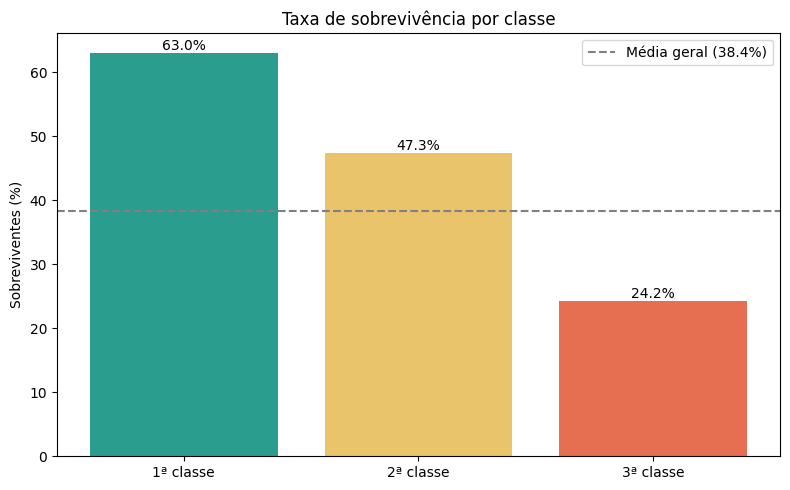

In [77]:
import matplotlib.pyplot as plt

os.makedirs(os.path.join("..", "images"), exist_ok=True)
plt.rcParams["figure.figsize"] = (8, 5)

dados_classe = pd.read_sql_query("""
    SELECT Pclass AS classe,
           ROUND(100.0 * SUM(Survived) / COUNT(*), 1) AS taxa
    FROM passengers
    GROUP BY Pclass
    ORDER BY Pclass
""", con)

# Taxa geral derivada dos dados (em vez de fixar 38,4 na mão)
taxa_geral = pd.read_sql_query(
    "SELECT 100.0 * SUM(Survived) / COUNT(*) AS taxa FROM passengers", con
)["taxa"][0]

fig, ax = plt.subplots()
barras = ax.bar(["1ª classe", "2ª classe", "3ª classe"], dados_classe["taxa"],
                color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.axhline(taxa_geral, color="gray", linestyle="--",
           label=f"Média geral ({taxa_geral:.1f}%)")
ax.set_title("Taxa de sobrevivência por classe")
ax.set_ylabel("Sobreviventes (%)")
ax.bar_label(barras, fmt="%.1f%%")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join("..", "images", "g1_sobrevivencia_classe.png"), dpi=110)
plt.show()

### Gráfico 2 — Sobrevivência por classe e sexo

O contraste salta aos olhos: mulheres (laranja) muito acima dos homens (azul) em todas as classes. Repare que a **mulher da 3ª (50%) supera o homem da 1ª (37%)** — o sexo pesou mais que a classe (Query 8).

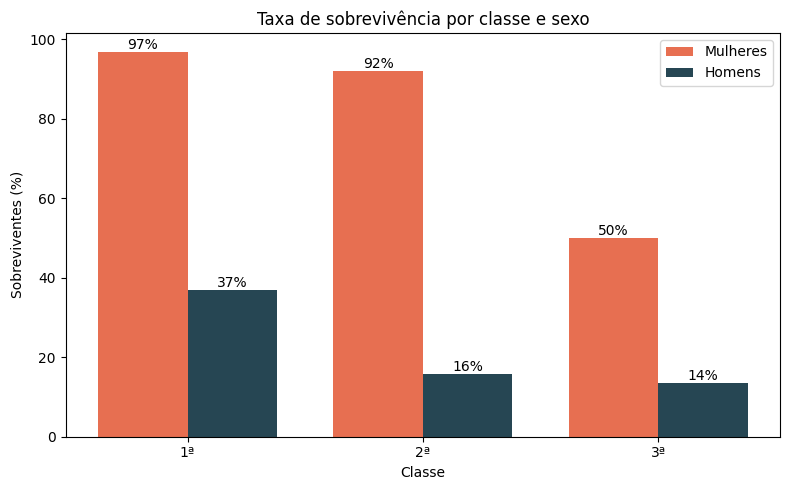

In [78]:
dados_cs = pd.read_sql_query("""
    SELECT Pclass AS classe, Sex AS sexo,
           ROUND(100.0 * SUM(Survived) / COUNT(*), 1) AS taxa
    FROM passengers
    GROUP BY Pclass, Sex
    ORDER BY Pclass, Sex
""", con)

tabela = dados_cs.pivot(index="classe", columns="sexo", values="taxa")
classes = ["1ª", "2ª", "3ª"]
mulheres = tabela["female"].tolist()
homens = tabela["male"].tolist()
posicoes = range(len(classes))
largura = 0.38

fig, ax = plt.subplots()
b1 = ax.bar([i - largura/2 for i in posicoes], mulheres, largura, label="Mulheres", color="#e76f51")
b2 = ax.bar([i + largura/2 for i in posicoes], homens, largura, label="Homens", color="#264653")
ax.set_xticks(list(posicoes))
ax.set_xticklabels(classes)
ax.set_title("Taxa de sobrevivência por classe e sexo")
ax.set_xlabel("Classe")
ax.set_ylabel("Sobreviventes (%)")
ax.bar_label(b1, fmt="%.0f%%")
ax.bar_label(b2, fmt="%.0f%%")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join("..", "images", "g2_classe_sexo.png"), dpi=110)
plt.show()

### Gráfico 3 — Distribuição das tarifas

A maioria se amontoa nas tarifas baixas, com uma cauda longa até £512. A **mediana (£14,45) fica à esquerda da média (£32,20)** — a assinatura visual de uma distribuição assimétrica à direita, em que a média é puxada pelos extremos (Seção 3).

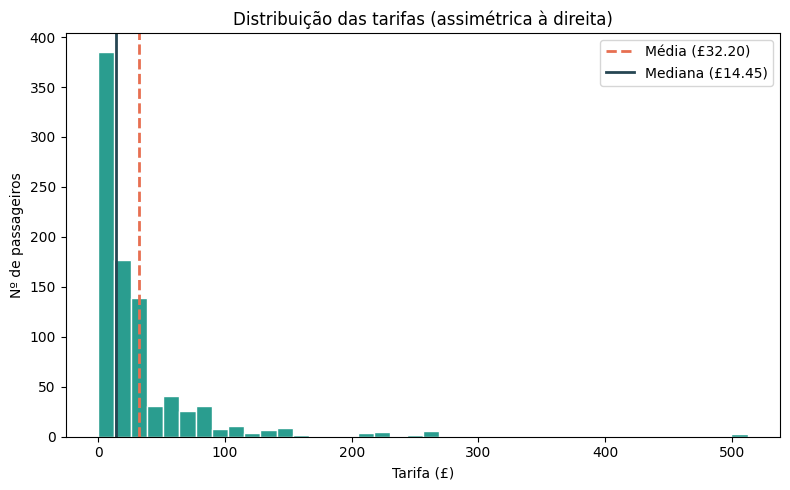

In [79]:
dados_tarifa = pd.read_sql_query("SELECT Fare FROM passengers", con)

# Usa as métricas já calculadas na Seção 3 (em vez de fixar os valores na mão)
fig, ax = plt.subplots()
ax.hist(dados_tarifa["Fare"], bins=40, color="#2a9d8f", edgecolor="white")
ax.axvline(media_tarifa, color="#e76f51", linestyle="--", linewidth=2,
           label=f"Média (£{media_tarifa:.2f})")
ax.axvline(mediana_tarifa, color="#264653", linestyle="-", linewidth=2,
           label=f"Mediana (£{mediana_tarifa:.2f})")
ax.set_title("Distribuição das tarifas (assimétrica à direita)")
ax.set_xlabel("Tarifa (£)")
ax.set_ylabel("Nº de passageiros")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join("..", "images", "g3_distribuicao_tarifas.png"), dpi=110)
plt.show()

> **Fim da Seção 5.** Os três gráficos foram salvos em `../images/` e serão reaproveitados no README. Próxima e última seção: as conclusões gerais.

## Seção 6 — Conclusões

Esta análise cruzou **SQL** (para perguntar aos dados) com **estatística em Python puro** (para entender as medidas por dentro). O que o Titanic revelou:

### Quem sobreviveu — e por quê
- A taxa geral foi **38,4%**: a maioria morreu.
- **Sexo foi o fator mais decisivo:** mulheres **74%** vs homens **19%**. O protocolo "mulheres e crianças primeiro" aparece claríssimo.
- **Classe veio logo atrás:** 1ª **63%** → 3ª **24%**. E a classe se refletia em tudo — tarifa (1ª pagava ~6x mais), idade (1ª ~13 anos mais velha) e até no porto de embarque.
- **Idade importou nos extremos:** crianças (**58%**) protegidas, idosos (**27%**) em desvantagem.
- O cruzamento **classe × sexo** foi o mais revelador: mulher de 1ª (**97%**) no topo, homem de 3ª (**14%**) no fundo — e uma mulher de 3ª (**50%**) tinha mais chance que um homem de 1ª (**37%**).

### Lições de análise de dados que levo deste projeto
1. **Correlação não é causa:** Cherbourg "sobreviveu mais", mas só porque concentrava 1ª classe. Variáveis aparentemente independentes (porto, família) contavam, no fundo, a mesma história social.
2. **A média pode enganar:** na tarifa, a média (£32,20) era mais que o **dobro** da mediana (£14,45). Em distribuições assimétricas, a mediana descreve melhor o "típico".
3. **Cuidado com dados faltando:** os 177 sem idade não eram aleatórios — concentravam-se na 3ª classe; ignorá-los distorceria a análise.

### O que pratiquei
Modelagem e carga em SQLite (connection/cursor, tipos, tratamento de `NULL`), **10 queries** com `GROUP BY`, `CASE`, agregações e cruzamentos, e a implementação **manual das 5 métricas** estatísticas — todas conferidas contra o pandas.

In [80]:
# Fim da análise — fechar a conexão com o banco
con.close()
print("Conexão fechada. Análise concluída.")

Conexão fechada. Análise concluída.
